# Probability Distributions
The probability distribution function, $P(x)$, is the probability of a variable $x$ having a given outcome, written as a function of that variable $x$.
The probability distribution function $P(x)$ is equal to the value of the probability function for that outcome, $f(x)$,
divided by the total probability for all possible outcomes, $P_{Total}$.
$$
P(x) = \frac{f(x)}{P_{Total}}
$$
The recipricol of the total probability for all possible outcomes is called the normalization constant. Multiplying by the normalization constant (i.e., dividing by the total probability) ensures that the total probability is equal to 1, that is, to 100%.

### Example

Consider rolling a fair, six-sided die. There's a "one in six" chance of rolling the number five. Why?

Well, the probability of rolling a number five is the probability function for that outcome, and we can set that equal to one: $f(5)=1$. In order to convert this function to actual probability distirbution function, we need to divide by the total probability. The total probability is the sum of the probabilities for all the possible outcomes we could get:
$$
\begin{aligned}
P_{total} &= f(1)+f(2)+f(3)+f(4)+f(5)+f(6) \\
&= 1+1+1+1+1+1\\
&=6
\end{aligned}
$$

So then the value of the probability distribution function would be:
$$
P(5) = \frac{f(5)}{P_{Total}} = \frac{1}{6}
$$

## For a Discrete Variable
It's only possible to get specific $x$ values when the variable is discrete. The probability of getting a specific value $x_i$ is given by $f(x_i)$, and the total probability is the sum of all these individual probabilities, $\sum_i f(x_i)$.

The probabiilty distribution function, which gives the actual probability of getting any of the specific $x$ values is given by:
$$
P(x_i) = \frac{f(x_i)}{\sum_j f(x_j)}
$$

## For a Continuous Variable
It's possible to get any $x$ value when the variable is continuous. The probability of getting the value $x$ is given by a continuous function of $x$ $f(x)$, and the total probability is the integral of that function over the full "domain" of $x$ (i.e., the sample space), $\int_{-\infty}^{\infty}f(x)dx$, where the default "domain" is $-\infty$ to $\infty$, but it could be something else, like $0$ to $\infty$, e.g., if $x$ refers to a radius. Integrating over all the probabilities for a continuous variable is like adding up all the probabilities for a discrete variable.

The probabiilty distribution function, which gives the actual probability of getting any $x$ value is given by:
$$
P(x) = \frac{f(x)}{\int_{-\infty}^{\infty}f(x)dx}
$$

In [ ]:
# Import the relevant libraries
# Note the new scientific python (scipy) and numerical python (numpy) libraries
# We are also importint a plotting library from matplotlib
import scipy
import numpy as np
import matplotlib.pyplot as plt

## Defining Functions
Previously, we used built-in functions from the Python libraries that we loaded. But that's not the only way to use a function! You can define your own functions!

A function is defined by using the `def` keyword, then providing the name of the function, with all the arguments to that function provided in parentheses. Then within the function, variables can be assigned and tasks can be carried out. Finally, the function includes a `return` keyword, which tells the computer what should be outcome of calling the function.
```
def function_name(arg1, arg2, arg3, arg4, ...):
    definitions and tasks ...
    return value
```
The arguments are the variables for the function, which is intuitive. However, sometimes you want the user to be able to change or select some parameter when calling the function, even if that parameter is not typically considered a variable in the function. As a result, the arguments that you set in the function definition should correspond to any value or parameter that you want the user to be able to select when calling the function.



In [ ]:
def double(x):
  factor=2
  return x*factor

In [ ]:
double(5)

In [ ]:
double_five = double(5)
print(double_five)

## Global vs Local Variables
* A "global" variable is defined outside of functions and is accessible anywhere in the jupyter notebook.
* A "local" variable is only defined within a function and is only accessible within that function - it's not accessible outside of the function. In fact, it only exists when that function is called, otherwise, it's not defined.

Understanding the difference between global and local variables is confusing because many people name their global and local variables the same name.

So first, let's see how these different types of variables work, and then we will see some examples of where they can be confusing...

In [ ]:
print(factor)

NameError: name 'factor' is not defined

In [ ]:
# Define a global variable
x=3
print("Original value of x: x =",x)

def x_function(): # here we don't have any input arguments...
  # Define a local variable
  x=4
  print("Value of x inside function: x =",x)
  return x

function_return = x_function()
print("Value from function call: ",function_return)

print("Value of x outside function: x =",x)


In [ ]:
# Example of where global and local variable names are confusing
x=3
def square(x):
  print("The value of x in the function is",x)
  return x**2

print(square(x))
print(square(2))


### Self Check 1
Explain (in words and/or code examples) what happens to produce the output of the previous cell. In your answer, explain when x is a global variable, when it is a local variable, and how `square(x)` differs when it's in the function definition line and in the function call line.

### Provide your answer here:






### Example - Maxwell Speed Distribution
The Maxwell Speed Distribution describes the probability of finding an ideal gas particle with a particular speed, given a particular mass of the gas particle and temperature of the gas. It's given by this function, where $v$ is the particle speed, $m$ is particle mass, $T$ is temperature of the gas, and $R$ is the gas constant.
$$
P(v,m,T) = 4\pi \Bigl(\frac{m}{2\pi RT}\Bigr)^{(3/2)} v^2 e^{-\frac{m v^2}{2RT}}
$$

In the speed distribution function (defined below), we typically think of a speed distribution as just a function of speed. But in this case, we may want the user to be able to compare the speed distributions of different types of atoms/molecules, which would require the user to change the mass of the particle, or we might want the user to compare the speed distributions at different temperatures. Thus, we include `mass` and `temperature` as arguments to the `speed_dist` function in addition to `speed` itself.

Note that we do include some "hard-coded" values when defining the function though. The gas constant is hard coded into the function, because there isn't typically a need for the user to change that value. If you did want to see how the gas constant impacts the speed distributions of molecules by changing its value, then it would be convenient to include it as an argument.

In [ ]:
def speed_dist(speed, mass, temperature):
    gasR = 8.314 # J/(mol K)
    alpha = (mass/(2 * gasR * temperature))
    return 4 * np.pi * ((alpha/ np.pi)**(3/2) ) * speed**2 * np.exp(-alpha * speed**2)


Note that we used the `numpy` library (which we imported as `np` as a shorthand) to define $\pi$ and the exponential number $e$ using `np.pi` and `np.exp`, respectively.

## Plotting Distribution Functions

If we want to plot the distribution, then we need to define the arguments to the distribution function, and we need to provide the specific x and y values for each point in the curve we wish to plot.

When you think of plotting a function on your calculator, you don't need to define the x and y values because the calculator does it automatically for you. But we are basically making the calculator plotting code here, so we need to tell the computer exactly what speed values (x-axis values) we want to evaluate the speed distribution for (to get y-axis values) in order to plot it.

In [ ]:
# Define different masses of nobel gases
neonMW = 20.180 * 10**-3
argonMW = 39.948 * 10**-3
kryptonMW = 83.798 * 10**-3

In [ ]:
# Define the x-axis values
# Create a numpy array of 3000 points from 0 to 1500
# Note, I selected 1500 as the max speed because I am familiar with the values
# but in other cases, you may need to play around with values to get a representative x-axis
x_axis = np.linspace(0,1500,3000)
print(x_axis)
print(len(x_axis))

In [ ]:
# Now make an numpy array for the y-axis values of the speed distribution for Neon at 298 K
# A numpy array is like a list, but can be multi-dimensional and used in various mathematical functions
neon_speed = np.array(speed_dist(x_axis, neonMW, 298))


In [ ]:
print(neon_speed)

### Self Check 2
Now go ahead and make a numpy array for the y-axis values of the speed distribution for Argon and Krypton at 298 K. Print the arrays after you create them.


### Actual Plotting
To plot the function, we will use the `matplotlib.pyplot` library that we imported as `plt` as a shorthand. We can use the simple `plt.plot` function, or the more "object-oriented" version that enables you to define more aspects of the plots more straightforwardly.

In the simple version, the input to the plotting function takes as arguments the x-axis values, the corresponding y-axis values, and then any other parameters like plot point `marker` or `linestyle` you want that's specific to that data.

```
plt.plot(x-values, y-values, param_name1 = param_value, param_name2 = param_value, ...)
```

Here is the simple `plt.plot` version of making a plot of the distribution function.

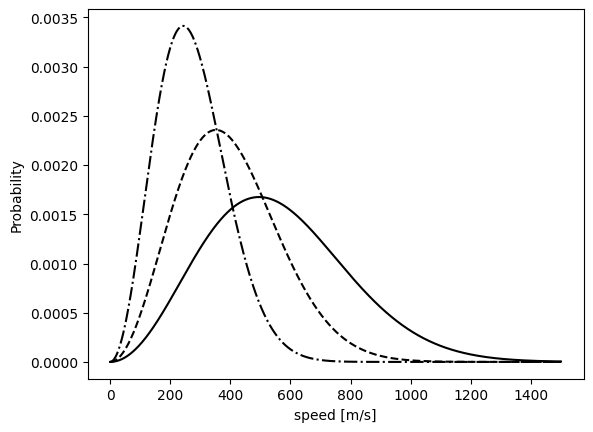

In [ ]:
plt.plot(x_axis, neon_speed, linestyle="-", color="Black")
plt.plot(x_axis, argon_speed, linestyle="--", color="Black")
plt.plot(x_axis, krypton_speed, linestyle="-.", color="Black")
plt.xlabel("speed [m/s]")
plt.ylabel("Probability")
plt.show()

In the more complex version, you can set up a whole figure (aspects of which are described in the MatPlotLib documentation [here](https://matplotlib.org/stable/users/explain/axes/axes_intro.html)), with a bit more flexibility in making multiple plots with axes specific to each plot.

Here, the input to the plotting function also takes as arguments the x-axis values, the corresponding y-axis values, and then any other parameters like plot point `marker` or `linestyle` you want that's specific to that data.

```
ax.plot(x-values, y-values, param_name1 = param_value, param_name2 = param_value, ...)
```

Here is the more complex `plt.subplots` version of making a plot of the distribution function.

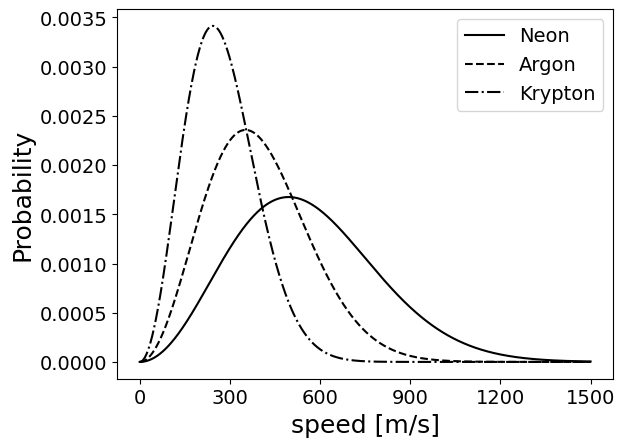

In [ ]:
fig , ax = plt.subplots()
ax.plot(x_axis, neon_speed, linestyle="-", color="Black", label="Neon")
ax.plot(x_axis, argon_speed, linestyle="--", color="Black", label="Argon")
ax.plot(x_axis, krypton_speed, linestyle="-.", color="Black", label="Krypton")
ax.set_xlabel("speed [m/s]", fontsize="18")
ax.set_ylabel("Probability", fontsize="18")
ax.set_xticks(np.arange(0,1600,300))
ax.tick_params(labelsize = "14")
plt.legend(fontsize="14")
plt.show()

## Total Probability

Now that we can see what the probability distribution looks like, let's make sure that it's normalized, so that the total probability equals 100%. The normalization constant is $\frac{1}{P_{Total}}$, and for a continuous variable,
$$
P_{Total} = \int_{-\infty}^{\infty}f(x)dx.
$$

So let's see what that integral is assuming that the $f(x)$ function is the Maxwell Speed Distribution.

To integrate a function numerically, we can use the `scipy.integrate.quad()` function.
```
scipy.integrate.quad(function_name, min_int_var, max_int_var, args=(additional arguments to the function))
```

This will print out a list containing the value of the integral as well as an estimate of the absolute error in the result. If we just want the integral, then we can add a `[0]` at the end to select the first item in the list that the function returns.


In [ ]:
# Here's the full output
scipy.integrate.quad(speed_dist, 0, np.inf, args=(neonMW, 298))

In [ ]:
# Here's just the value of the integral
scipy.integrate.quad(speed_dist, 0, np.inf, args=(neonMW, 298))[0]

### Self Check 3
Now go ahead and calculate the total probability for the distributions for Argon and Krypton at 298 K.

Then round all the values so that the numerical decimal value isn't shown anymore.

Is the Maxwell Speed Distribution function $f(x)$ normalized already or will you need to redefine it with an explicit normalization constant?

We can visually represent the integration by including the `ax.fill_between()` function that fills between the lines given by the first and second arguments to the function.

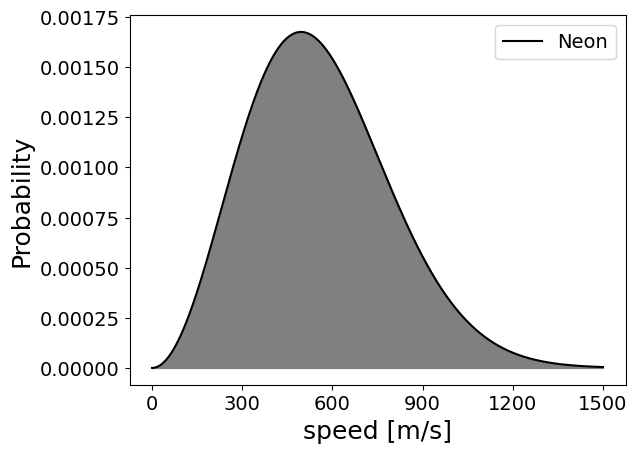

In [ ]:
fig , ax = plt.subplots()
ax.plot(x_axis, neon_speed, linestyle="-", color="Black", label="Neon")
ax.set_xlabel("speed [m/s]", fontsize="18")
ax.set_ylabel("Probability", fontsize="18")
ax.set_xticks(np.arange(0,1600,300))
ax.tick_params(labelsize = "14")
ax.fill_between(x_axis, neon_speed, color="gray")
plt.legend(fontsize="14")
plt.show()

### Self Check 4 - Challenge

1.   Make a function that will return the probability of finding an ideal gas particle within a range of speeds.
2.   Make a plot that allows you to visualize the integral over that region of space.



## Characterizing the Distribution

Probability distributions can be characterized by many different summary statistics.

One way to characterize the distribution is to calculate the **mode** of the distribution, which is the maximum value.
$$
\frac{P(x)}{dx} = 0
$$

Another way to characterize the distribution is by using the moments of the distribution.
* The **first moment** is the **average** of the distribution.  
* The square root of the **second moment** is the root mean square (**rms**) of the distribution.

Moments are calculated by taking the integral of the distribution multiplied by different orders of the sample variable itself.

First moment:
$$
<x> = \int_{-\infty}^{\infty} x^1 P(x)dx
$$

Second moment:
$$
<x^2> = \int_{-\infty}^{\infty} x^2 P(x)dx
$$

nth moment:
$$
<x^n> = \int_{-\infty}^{\infty} x^n P(x)dx
$$

To calculate the mode, the max value of the function, use the `scipy.optimize.fmin()` function as shown below. Note that we are calculating a minimum value, so we need to "flip" the function so that a max becomes a min. We do this by adding a negative sign to the `speed_dist()` function - this works, but you have to be careful with it sometimes.

In [ ]:
minimum=scipy.optimize.fmin(lambda speed: speed_dist(speed,argonMW, 298),600)

In [ ]:
print(minimum)

In [ ]:
minimum=scipy.optimize.fmin(lambda speed: -speed_dist(speed,argonMW, 298),0)

In [ ]:
print(minimum)

In [ ]:
mp_speed = np.zeros(3)
print(mp_speed)
count = 0
for mass in (neonMW, argonMW, kryptonMW):
    print(mass)
    print(count)
    mp_speed[count] = round(np.take(scipy.optimize.fmin(lambda speed: -speed_dist(speed,mass, 298),0),0),1)
    count+=1
print(mp_speed)

In [ ]:
import contextlib
import io
import sys
np.set_printoptions(legacy='1.25')

def mp(mass, temperature):
    silent_output = io.StringIO()
    with contextlib.redirect_stdout(silent_output):
        mp_value = scipy.optimize.fmin(lambda speed: -speed_dist(speed,mass, temperature),0)[0]
    return mp_value
mp(argonMW,298)

### First moment
Write a function to calculate the first moment

In [ ]:
def first_moment_func(speed, mass, temperature):
    gasR = 8.314
    alpha = (mass/(2 * gasR * temperature))
    return (4 * np.pi * ((alpha/ np.pi)**(3/2) ) * speed**2 * np.exp(-alpha * speed**2))*speed


scipy.integrate.quad(first_moment_func, 0, np.inf, args=(argonMW, 298))[0]

In [ ]:
def first_moment(mass, temperature):
  def first_moment_func(speed, mass, temperature):
    return speed_dist(speed,mass,temperature)*speed
  return scipy.integrate.quad(first_moment_func, 0, np.inf, args=(mass, temperature))[0]

first_moment(argonMW,298)

In [ ]:
def first_moment(mass, temperature):
  def speed_dist(speed, mass, temperature):
    gasR = 8.314
    alpha = (mass/(2 * gasR * temperature))
    return (4 * np.pi * ((alpha/ np.pi)**(3/2) ) * speed**2 * np.exp(-alpha * speed**2))
  def first_moment_func(speed, mass, temperature):
    return speed_dist(speed,mass,temperature)*speed
  return scipy.integrate.quad(first_moment_func, 0, np.inf, args=(mass, temperature))[0]
first_moment(argonMW,298)

### Self Check 5
Write a function to calculate the root mean square speed for each distribution.

Plot the most probable speed, average speed, and rms speed on the distribution for Argon at 298K.

### Self Check 6 - Challenge!
Now go ahead and use what you know about for loops to make three subplots within your figure, each comparing Neon, Argon, and Krypton distributions at different temperatures: 100K, 298K, 500K.